# Dự đoán bệnh gan dựa trên kết quả xét nghiệm
**Mục tiêu**: *Dựa vào các chỉ số trong kết quả xét nghiệm máu mà đưa ra dự đoán một người có bị bệnh gan hay không*


Nội dung notebook:
1. Đọc dữ liệu
2. Quan sát dữ liệu 
3. Chia dữ liệu train, dữ liệu test
4. tiền xử lý
5. Tìm thuộc tính quan trọng dựa trên Random Forest(chỉ dùng train)
6. Áp dụng KNN để dự đoán(học ở train)
7. Báo cáo kết quả

#### 1. Đọc dữ liệu

In [2]:
#import thư viện
import pandas as pd
import numpy as np
import os


1. Đọc dữ liệu từ file, in ra số bộ, số thuộc tính

In [3]:
#đọc data
DATA_PATH = "data\Liver_Patient_Dataset_LPD.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu tại {DATA_PATH}. Hãy kiểm tra đường dẫn và upload file vào đúng vị trí.")

df_raw = pd.read_csv(DATA_PATH, encoding='latin1')  # hoặc 'cp1252'

df_raw.shape # in ra số bộ, các thuộc tính

<>:2: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
<>:2: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
C:\Users\nahno\AppData\Local\Temp\ipykernel_11680\71780983.py:2: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
  DATA_PATH = "data\Liver_Patient_Dataset_LPD.csv"


(30691, 11)

In [4]:
def clean_column_names(df):
    """
    Chuẩn hóa tên cột: bỏ khoảng trắng thừa, ký tự đặc biệt
    """
    df_clean = df.copy()
    
    # Ép toàn bộ tên cột về string (RẤT QUAN TRỌNG)
    df_clean.columns = df_clean.columns.astype(str)
    
    # Mapping từ tên cũ sang tên mới
    column_mapping = {
        'Age of the patient': 'Age of the patient',
        'Gender of the patient': 'Gender of the patient',
        'Total Bilirubin': 'Total Bilirubin',
        'Direct Bilirubin': 'Direct Bilirubin',
        'Alkphos Alkaline Phosphotase': 'Alkphos Alkaline Phosphotase',  # 
        ' Sgpt Alamine Aminotransferase': 'Sgpt Alamine Aminotransferase',  
        'Sgot Aspartate Aminotransferase': 'Sgot Aspartate Aminotransferase',  
        'Total Protiens': 'Total Protiens',
        ' ALB Albumin': 'ALB Albumin',
        'A/G Ratio Albumin and Globulin Ratio': 'A/G Ratio Albumin and Globulin Ratio',
        'Result': 'Result'
    }
    
    print("🔧 CHUẨN HÓA TÊN CỘT:")
    print("-" * 40)
    
    # Đổi tên từng cột
    rename_dict = {}
    for old_name in df_clean.columns:
        # Tìm tên mới trong mapping
        new_name = None
        for key, value in column_mapping.items():
            if str(key).strip() == str(old_name).strip():
                new_name = value
                break
        
        # Nếu không tìm thấy, chuẩn hóa chung
        if new_name is None:
            # Chuẩn hóa: chữ thường, thay khoảng trắng bằng _
            new_name = old_name.strip().lower().replace(' ', '_')
            new_name = ''.join(c for c in new_name if c.isalnum() or c == '_')
        
        rename_dict[old_name] = new_name
        print(f"  '{old_name}' → '{new_name}'")
    
    # Áp dụng đổi tên
    df_clean = df_clean.rename(columns=rename_dict)
    
    print(f"\n✅ Đã chuẩn hóa {len(rename_dict)} cột")
    return df_clean

# Sử dụng
df_raw = clean_column_names(df_raw)
print("\nTên cột mới:", df_raw.columns.tolist())

🔧 CHUẨN HÓA TÊN CỘT:
----------------------------------------
  'Age of the patient' → 'Age of the patient'
  'Gender of the patient' → 'Gender of the patient'
  'Total Bilirubin' → 'Total Bilirubin'
  'Direct Bilirubin' → 'Direct Bilirubin'
  ' Alkphos Alkaline Phosphotase' → 'Alkphos Alkaline Phosphotase'
  ' Sgpt Alamine Aminotransferase' → 'Sgpt Alamine Aminotransferase'
  'Sgot Aspartate Aminotransferase' → 'Sgot Aspartate Aminotransferase'
  'Total Protiens' → 'Total Protiens'
  ' ALB Albumin' → 'ALB Albumin'
  'A/G Ratio Albumin and Globulin Ratio' → 'A/G Ratio Albumin and Globulin Ratio'
  'Result' → 'Result'

✅ Đã chuẩn hóa 11 cột

Tên cột mới: ['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', 'Alkphos Alkaline Phosphotase', 'Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', 'ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']


2. In ra vài dữ liệu đầu tiên

In [5]:
df_raw.head(10) # kết quả 1 là bị gan, 2 là ko bị

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1
5,46.0,Male,1.8,0.7,208.0,19.0,14.0,7.6,4.4,1.30,1
6,26.0,Female,0.9,0.2,154.0,NaN,12.0,7.0,3.5,1.00,1
7,29.0,Female,0.9,0.3,202.0,14.0,11.0,6.7,3.6,1.10,1
8,17.0,Male,0.9,0.3,202.0,22.0,19.0,7.4,4.1,1.20,2
9,55.0,Male,0.7,0.2,290.0,53.0,58.0,6.8,3.4,1.00,1


3. In ra vài dữ liệu cuối cùng

In [6]:
df_raw.tail(10)

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
30681,31.0,NaN,NaN,NaN,415.0,407.0,576.0,6.4,3.2,1.00,1
30682,24.0,NaN,NaN,NaN,208.0,17.0,15.0,7.0,3.6,1.00,2
30683,58.0,NaN,NaN,NaN,275.0,48.0,178.0,6.5,3.2,0.90,2
30684,51.0,Male,0.9,0.3,293.0,232.0,245.0,6.8,3.1,0.80,1
30685,50.0,Male,0.9,0.3,293.0,232.0,245.0,6.8,3.1,0.80,1
30686,50.0,Male,2.2,1.0,610.0,17.0,28.0,7.3,2.6,0.55,1
30687,55.0,Male,2.9,1.3,482.0,22.0,34.0,7.0,2.4,0.50,1
30688,54.0,Male,6.8,3.0,542.0,116.0,66.0,6.4,3.1,0.90,1
30689,48.0,Female,1.9,1.0,231.0,16.0,55.0,4.3,1.6,0.60,1
30690,30.0,Male,3.1,1.6,253.0,80.0,406.0,6.8,3.9,1.30,1


#### 2. Exploratory Data Analysis(EDA)

In [7]:
df = df_raw.copy()

1. thông tin cơ bản về dữ liệu

In [8]:
df.info() #đếm số lượng không null của từng cột và loại dữ liệu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    30689 non-null  float64
 1   Gender of the patient                 29789 non-null  object 
 2   Total Bilirubin                       30043 non-null  float64
 3   Direct Bilirubin                      30130 non-null  float64
 4   Alkphos Alkaline Phosphotase          29895 non-null  float64
 5   Sgpt Alamine Aminotransferase         30153 non-null  float64
 6   Sgot Aspartate Aminotransferase       30229 non-null  float64
 7   Total Protiens                        30228 non-null  float64
 8   ALB Albumin                           30197 non-null  float64
 9   A/G Ratio Albumin and Globulin Ratio  30132 non-null  float64
 10  Result                                30691 non-null  int64  
dtypes: float64(9), 

In [9]:
df.isnull().sum() #đếm số lượng null của từng cột

Age of the patient                        2
Gender of the patient                   902
Total Bilirubin                         648
Direct Bilirubin                        561
Alkphos Alkaline Phosphotase            796
Sgpt Alamine Aminotransferase           538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
ALB Albumin                             494
A/G Ratio Albumin and Globulin Ratio    559
Result                                    0
dtype: int64

In [10]:
def encode_gender(df, col='Gender of the patient'):
    mapping = {
        'male': 1, #nam là 1, nữ là 2
        'female': 2
    }
    
    # Kiểm tra nếu cột đã được encode rồi
    if df[col].dtype in ['int64', 'float64']:
        print(f"Cột '{col}' đã được mã hóa rồi (kiểu dữ liệu số)")
        return df
    
    df[col] = (
        df[col]
        .astype(str)       
        .str.strip()
        .str.lower()
        .map(mapping)
    )
    return df
df = encode_gender(df)

In [11]:
print(df['Gender of the patient'].value_counts())
print("\nKiểm tra 5 dòng đầu:")
print(df[['Gender of the patient']].head(10))

Gender of the patient
1.0    21986
2.0     7803
Name: count, dtype: int64

Kiểm tra 5 dòng đầu:
   Gender of the patient
0                    2.0
1                    1.0
2                    1.0
3                    1.0
4                    1.0
5                    1.0
6                    2.0
7                    2.0
8                    1.0
9                    1.0


In [12]:
def comment_from_data(df): # cải tiến hàm describe nhưng có thêm CV và đánh giá
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Tính toán các thống kê cơ bản
    count = numeric_df.count() # đếm
    mean = numeric_df.mean() # trung bình
    std = numeric_df.std() # phương sai
    min_val = numeric_df.min()
    max_val = numeric_df.max() 
    missing_data = numeric_df.isnull().sum()
    # Tính các phần trăm
    q25 = numeric_df.quantile(0.25)  # 25%
    q50 = numeric_df.quantile(0.50)  # 50% (median)
    q75 = numeric_df.quantile(0.75)  # 75%
    
    CV = std / mean

    # Tạo label dựa trên CV
    labels = []
    for cv in CV:
        if pd.isna(cv):
            labels.append('Không xác định')
        elif cv < 0.3:
            labels.append('Ổn định')
        elif cv < 0.6:
            labels.append('Phân tán vừa')
        elif cv < 1.0:
            labels.append('Phân tán mạnh')
        else:
            labels.append('Rất không ổn định')
    
    return pd.DataFrame({
        'count': count,
        'mean': mean,
        'std': std,
        'min': min_val,
        '25%': q25,
        '50%': q50,
        '75%': q75,
        'max': max_val,
        'CV': CV,
        'Độ phân tán dữ liệu': labels,
        'missing dữ liệu': missing_data
    })


comment = comment_from_data(df)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 50)

print(comment)

                                      count        mean         std   min    25%    50%    75%     max        CV Độ phân tán dữ liệu  missing dữ liệu
Age of the patient                    30689   44.107205   15.981043   4.0   32.0   45.0   55.0    90.0  0.362323        Phân tán vừa                2
Gender of the patient                 29789    1.261942    0.439699   1.0    1.0    1.0    2.0     2.0  0.348430        Phân tán vừa              902
Total Bilirubin                       30043    3.370319    6.255522   0.4    0.8    1.0    2.7    75.0  1.856062   Rất không ổn định              648
Direct Bilirubin                      30130    1.528042    2.869592   0.1    0.2    0.3    1.3    19.7  1.877954   Rất không ổn định              561
Alkphos Alkaline Phosphotase          29895  289.075364  238.537589  63.0  175.0  209.0  298.0  2110.0  0.825174       Phân tán mạnh              796
Sgpt Alamine Aminotransferase         30153   81.488641  182.158850  10.0   23.0   35.0   62.0  2000

**Phân tích tổng quan dữ liệu**
Tổng mẫu: ~30,000-31,000 bệnh nhân (tùy cột có missing data)
Dữ liệu khá đầy đủ: Missing ít
1. Age of the patient
    - missing dữ liệu: 2
    - Độ tuổi trung bình: 44
    - 50% bệnh nhân từ 32-55 tuổi
    - Phân bố khá đối xứng (mean ≈ median)
2. Gender of the patient
    - Tỷ lệ nam > nữ trong dataset, tỉ lệ nam và nữ khá lệch -> không cân bằng giới tính
    - missing dữ liệu: 902
3. Total Bilirubin 
    - missing dữ liệu: 648
    - bị outline nặng(tồn tại cái max là 75)
    - dữ liệu bị lệch phải(trung bình > trung vị)
    - so sánh với tiêu chuẩn y tế, chỉ số total Blirubin đc coi là bình thường trong khoảng: [0.3, 1.2]  # mg/dL, như vậy khoảng độ gần 50% nhóm người là đã sở hữu chỉ số Bilirubin cao 
    - độ phân tán dữ liệu cho biết dữ liệu rất ko ổn định
4. Direct Bilirubin
    - missing dữ liệu: 561
    - bị outline nặng(tồn tại cái max là 19.7)
    - dữ liệu có xu hướng nghiêng về bên trái
    - so sánh với với tiêu chuẩn y tế, chỉ số Direct Bilirubin được coi là bình thường trong khoảng: [0.0, 0.3] mg/dL, như vậy khoảng độ gần 50% nhóm người sở hữu tỉ lệ Direct Bilirubin cao hơn mức bình thường
    - độ phân tán dữ liệu cho biết dữ liệu rất ko ổn định
5. Alkphos Alkaline Phosphotase (ALP)
    - Missing dữ liệu: 796
    - Outliers: Xuất hiện tình trạng nhiễu (outliers) cực mạnh khi giá trị lớn nhất (max) lên tới 2110, trong khi trung bình chỉ là 289.
    - Phân bố: Dữ liệu lệch phải (Mean > Median: 289 > 209).
    - So sánh với tiêu chuẩn y tế: - Mức bình thường: 44 - 147 IU/L (có thể thay đổi nhẹ tùy phòng xét nghiệm).
    - Nhận xét: Với trung vị (50%) là 209, có hơn 75% bệnh nhân trong tập dữ liệu này sở hữu mức Alkphos vượt ngưỡng bình thường.
    - Độ phân tán: Phân tán mạnh (CV ≈ 0.82), dữ liệu biến thiên lớn.
6. Sgpt Alamine Aminotransferase (ALT)
    - Missing dữ liệu: 538
    - Outliers: Outlier cực lớn (max 2000), cách rất xa giá trị trung vị (35).
    - Phân bố: Lệch phải rất nặng (Mean gấp hơn 2 lần Median).
    - So sánh với tiêu chuẩn y tế: - Nam: 7 - 55 U/L | Nữ: 7 - 45 U/L.
    - Nhận xét: Khoảng 50% bệnh nhân có chỉ số trong ngưỡng an toàn (Median = 35), tuy nhiên nhóm 25% cuối (từ 75% đến max) có chỉ số tăng vọt, cho thấy tình trạng tổn thương gan cấp tính ở một nhóm nhỏ bệnh nhân.
    - Độ phân tán: Rất không ổn định (CV > 2).
7. Sgot Aspartate Aminotransferase (AST)
    - Missing dữ liệu: 462
    - Outliers: Có biến động khủng khiếp nhất trong bộ dữ liệu (max 4929).
    - Phân bố: Lệch phải cực bộ (Mean 111.4 so với Median 42).
    - So sánh với tiêu chuẩn y tế: - Nam: 8 - 48 U/L | Nữ: 8 - 43 U/L.
    - Nhận xét: Chỉ số trung vị (42) nằm sát ngưỡng giới hạn cao. Điều này có nghĩa là gần 50% bệnh nhân trong mẫu đã bắt đầu vượt ngưỡng hoặc có dấu hiệu bất thường về AST.
    - Độ phân tán: Rất không ổn định (CV ~ 2.5).
8. Total Proteins (Protein tổng phần)
    - Missing dữ liệu: 463
    - Đặc điểm: Không có outlier đáng kể (min 2.7, max 9.6).
    - Phân bố: Khá đối xứng và tập trung (Mean 6.48 ≈ Median 6.6).
    - So sánh với tiêu chuẩn y tế: - Mức bình thường: 6.0 - 8.3 g/dL.
    - Nhận xét: Dữ liệu cho thấy đa số bệnh nhân (hơn 75%) có tổng lượng protein nằm trong hoặc sát ngưỡng bình thường. Chỉ một số ít bị - giảm protein (dưới 6.0).
    - Độ phân tán: Ổn định (CV thấp nhất: 0.16).
9. ALB Albumin
    - Missing dữ liệu: 494
    - Đặc điểm: Dữ liệu ổn định, không có biến động bất thường.
    - Phân bố: Phân bố chuẩn (Mean 3.1 ≈ Median 3.1).
    - So sánh với tiêu chuẩn y tế: - Mức bình thường: 3.4 - 5.4 g/dL.
    - Nhận xét: Chỉ số trung vị (3.1) thấp hơn mức bình thường tối thiểu (3.4). Điều này cho thấy phần lớn bệnh nhân (>50%) trong dataset đang gặp tình trạng giảm Albumin (thường liên quan đến bệnh gan mãn tính).
    - Độ phân tán: Ổn định.
10. A/G Ratio (Tỷ lệ Albumin/Globulin)
    - Missing dữ liệu: 559
    - Phân bố: Lệch nhẹ về bên phải.
    - So sánh với tiêu chuẩn y tế: - Mức bình thường: 1.1 - 2.5.
    - Nhận xét: Với giá trị 75% chỉ dừng ở mức 1.1, điều này có nghĩa là có tới 75% bệnh nhân trong bộ dữ liệu có tỷ lệ A/G thấp hơn bình - thường. Đây là dấu hiệu bệnh lý gan mật rất rõ rệt.
    - Độ phân tán: Phân tán vừa.
11. Result (Kết quả chẩn đoán)
    - Missing dữ liệu: 0 (Đây là cột đầy đủ nhất).
    - Phân tích: - Giá trị 1 (thường là có bệnh) và 2 (không bệnh).
    - Trung vị là 1.0 và Mean là 1.28 cho thấy số lượng bệnh nhân mắc bệnh (nhãn 1) chiếm ưu thế áp đảo trong bộ dữ liệu này so với người khỏe mạnh.



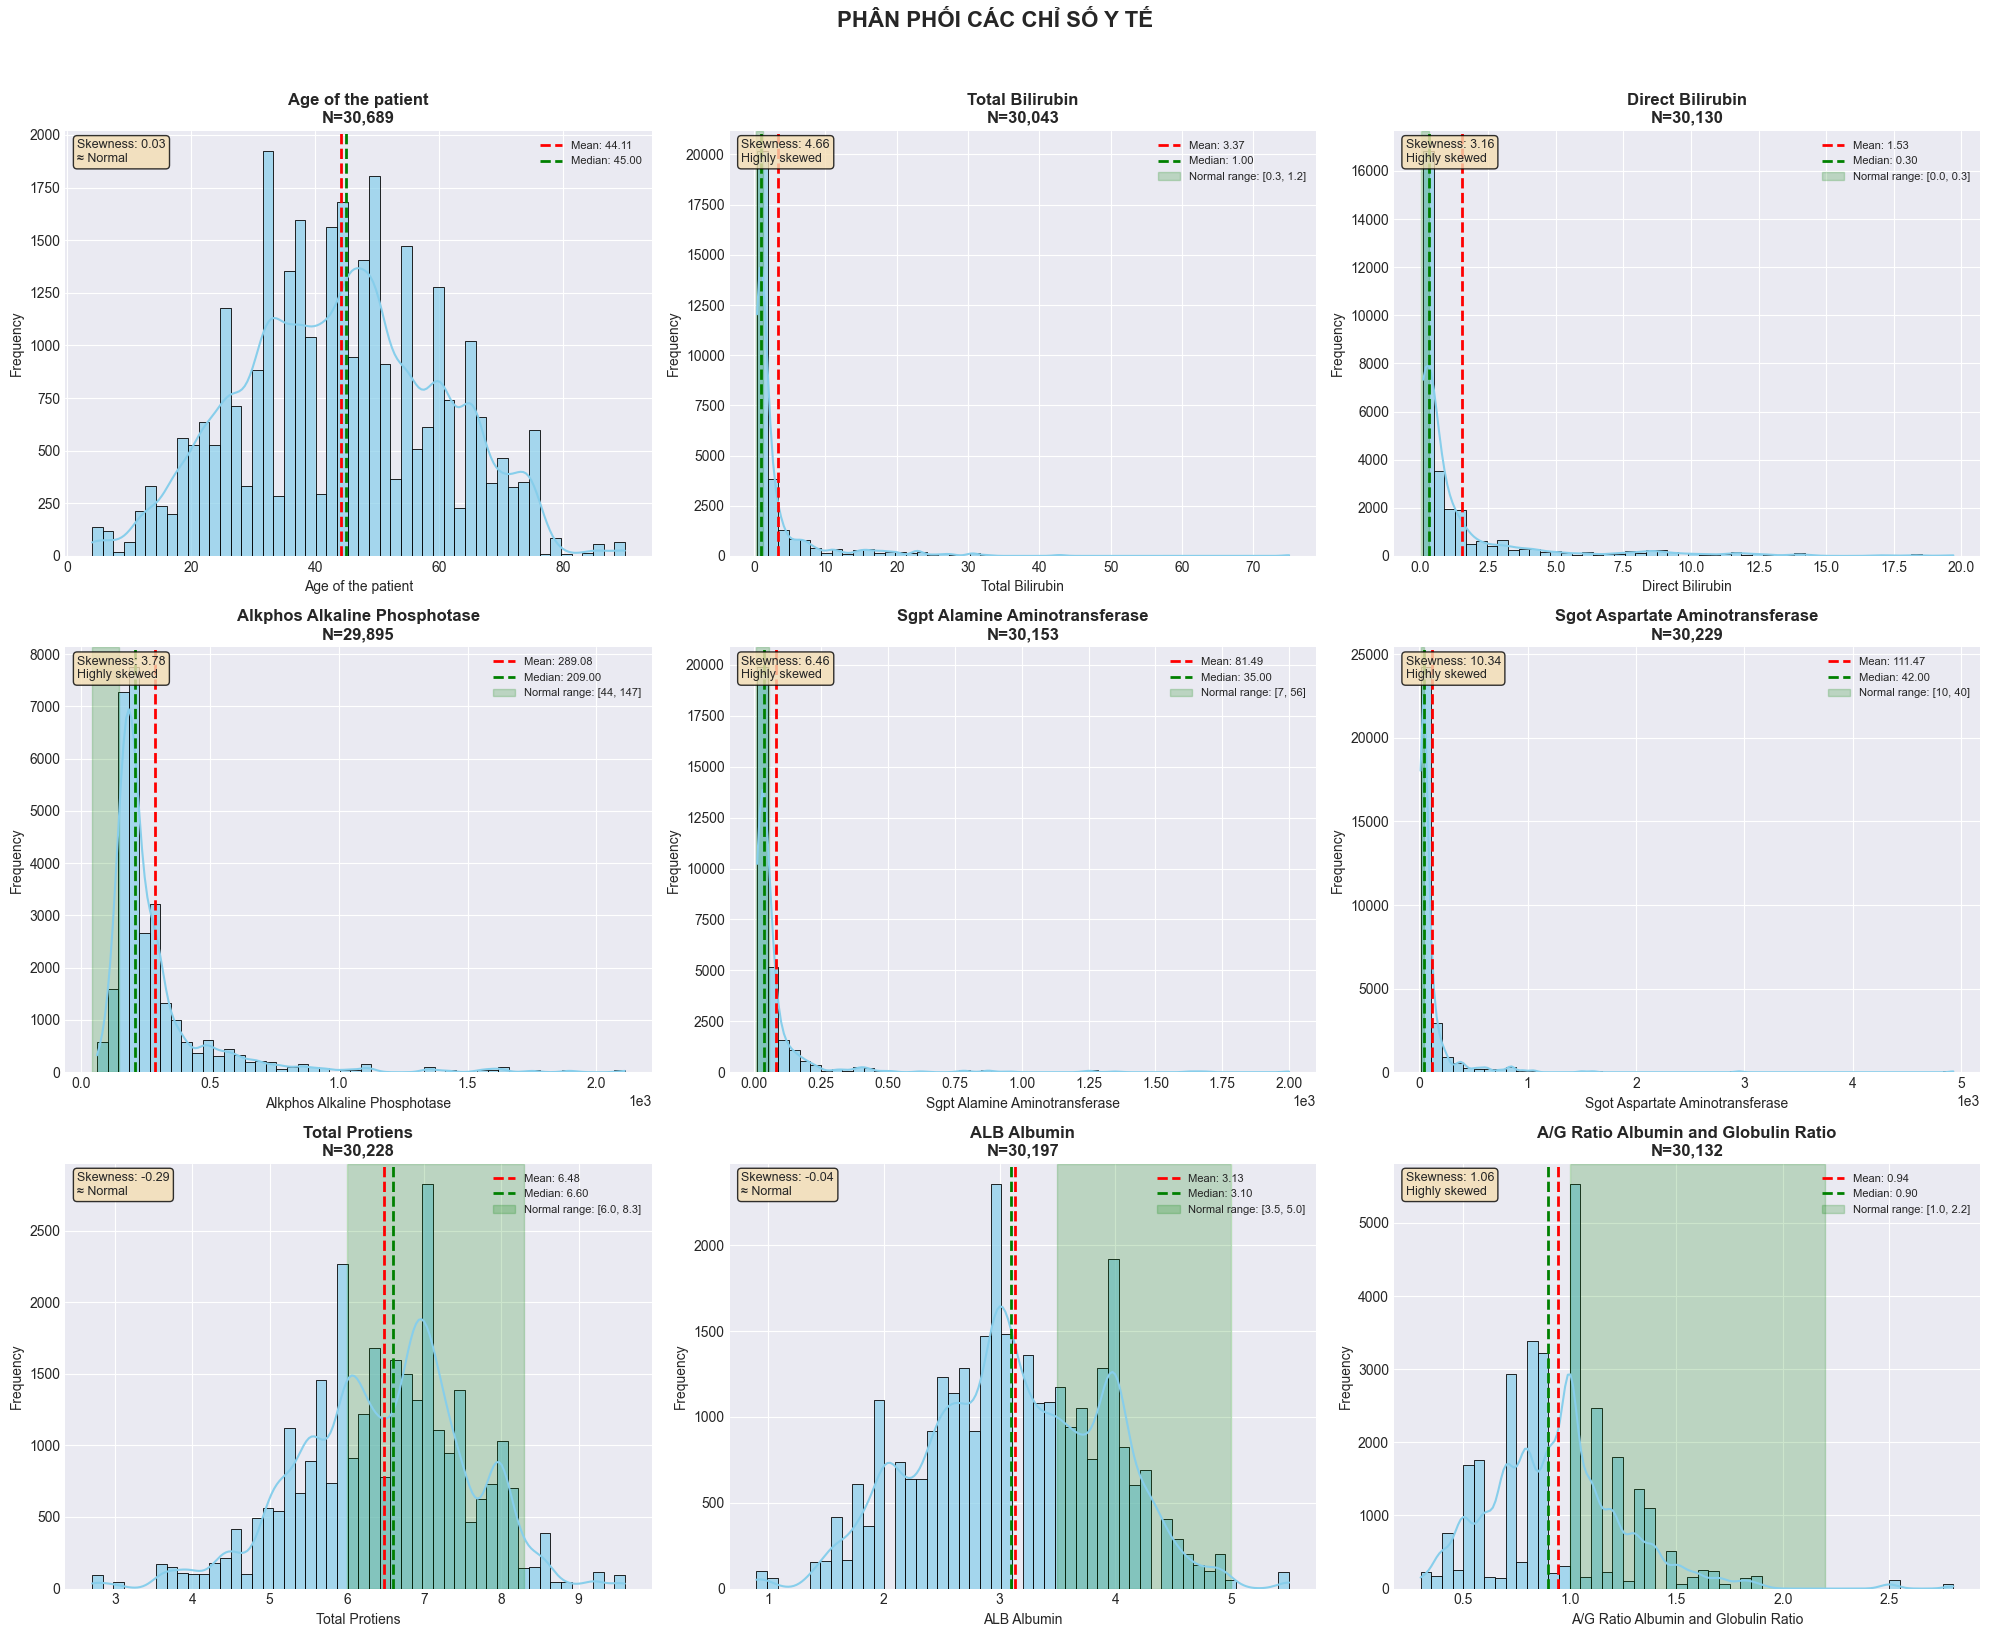

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

def visualize_medical_data(df, figsize=(20, 16)):
    """
    Vẽ biểu đồ toàn diện cho dữ liệu y tế
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame chứa dữ liệu y tế
    figsize : tuple
        Kích thước figure tổng
    """
    
    # Cài đặt style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Tạo figure lớn với nhiều subplots
    fig = plt.figure(figsize=figsize)
    
    # Danh sách các chỉ số cần visualize
    medical_columns = [
        'Age of the patient',
        'Total Bilirubin',
        'Direct Bilirubin',
        'Alkphos Alkaline Phosphotase',
        'Sgpt Alamine Aminotransferase',
        'Sgot Aspartate Aminotransferase',
        'Total Protiens',
        'ALB Albumin',
        'A/G Ratio Albumin and Globulin Ratio'
    ]
    
    # Lọc chỉ các cột có trong dataframe
    plot_columns = [col for col in medical_columns if col in df.columns]
    n_plots = len(plot_columns)
    
    # Tính layout
    n_rows = (n_plots + 2) // 3  # Làm tròn lên, tối đa 3 cột
    n_cols = min(3, n_plots)
    
    # Tiêu chuẩn y tế để so sánh
    medical_standards = {
        'Total Bilirubin': (0.3, 1.2),  # (min_normal, max_normal)
        'Direct Bilirubin': (0.0, 0.3),
        'Alkphos Alkaline Phosphotase': (44, 147),  # U/L cho người lớn
        'Sgpt Alamine Aminotransferase': (7, 56),   # U/L
        'Sgot Aspartate Aminotransferase': (10, 40), # U/L
        'Total Protiens': (6.0, 8.3),  # g/dL
        'ALB Albumin': (3.5, 5.0),     # g/dL
        'A/G Ratio Albumin and Globulin Ratio': (1.0, 2.2)
    }
    
    # Vẽ từng biểu đồ
    for idx, col in enumerate(plot_columns, 1):
        ax = plt.subplot(n_rows, n_cols, idx)
        
        # Kiểm tra dữ liệu
        data = df[col].dropna()
        if len(data) == 0:
            ax.text(0.5, 0.5, f'No data for {col}', 
                   ha='center', va='center', transform=ax.transAxes)
            continue
        
        # Vẽ histogram với KDE
        sns.histplot(data=data, kde=True, ax=ax, bins=50, 
                    color='skyblue', edgecolor='black', alpha=0.7)
        
        # Thêm đường thẳng cho mean, median
        mean_val = data.mean()
        median_val = data.median()
        
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, 
                  label=f'Median: {median_val:.2f}')
        
        # Thêm vùng tiêu chuẩn y tế nếu có
        if col in medical_standards:
            normal_min, normal_max = medical_standards[col]
            ax.axvspan(normal_min, normal_max, alpha=0.2, color='green',
                      label=f'Normal range: [{normal_min}, {normal_max}]')
        
        # Tính và hiển thị skewness
        skewness = data.skew()
        skew_text = f'Skewness: {skewness:.2f}\n'
        if abs(skewness) < 0.5:
            skew_text += '≈ Normal'
        elif abs(skewness) < 1:
            skew_text += 'Moderately skewed'
        else:
            skew_text += 'Highly skewed'
        
        # Thêm text box với thông tin
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.02, 0.98, skew_text, transform=ax.transAxes, fontsize=9,
               verticalalignment='top', bbox=props)
        
        # Cài đặt tiêu đề và labels
        ax.set_title(f'{col}\nN={len(data):,}', fontsize=12, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.legend(loc='upper right', fontsize=8)
        
        # Định dạng trục x cho số lớn
        if data.max() > 1000:
            ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    
    plt.suptitle('PHÂN PHỐI CÁC CHỈ SỐ Y TẾ', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

# Sử dụng:
fig = visualize_medical_data(df)

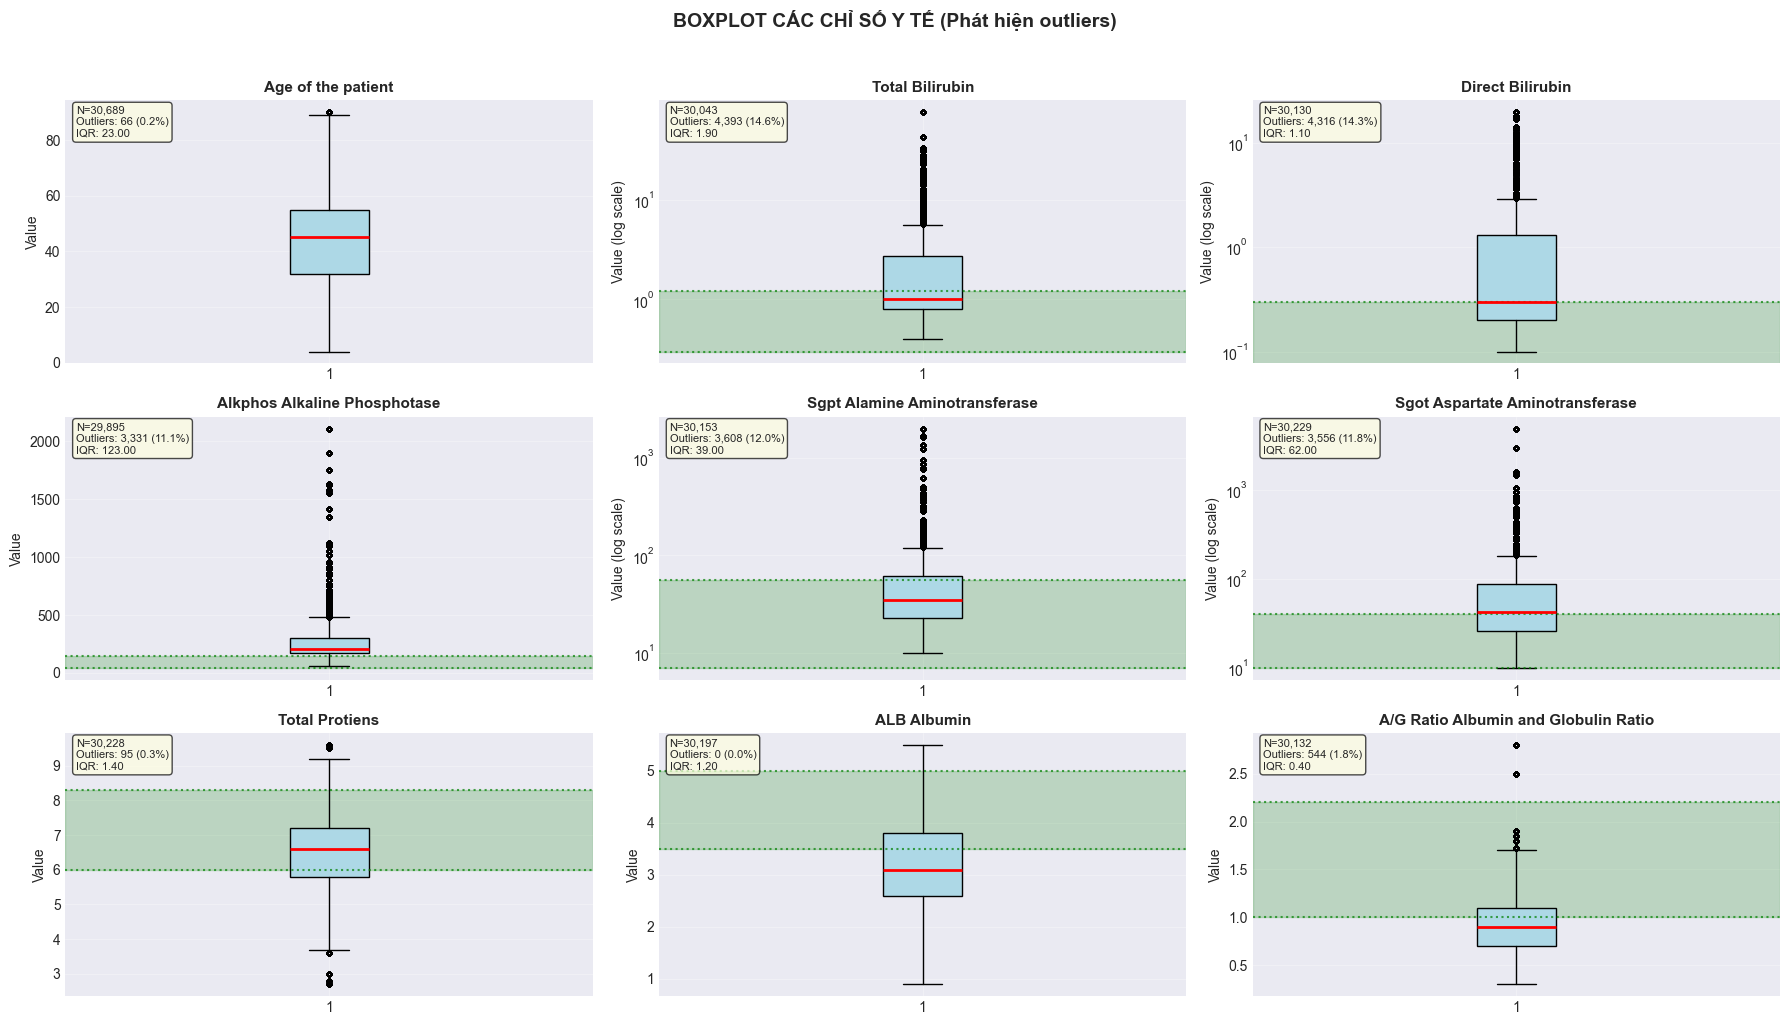

In [14]:
def plot_medical_boxplots(df, figsize=(18, 10)):
    """
    Vẽ boxplot cho tất cả chỉ số y tế
    """
    # Chọn các cột số
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Loại bỏ cột kết quả nếu có
    if 'Result' in numeric_cols:
        numeric_cols.remove('Result')
    if 'Gender of the patient' in numeric_cols:
        numeric_cols.remove('Gender of the patient')
    
    # Tính số lượng subplot
    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    # Tiêu chuẩn y tế (màu xanh lá cho vùng bình thường)
    medical_standards = {
        'Total Bilirubin': (0.3, 1.2),
        'Direct Bilirubin': (0.0, 0.3),
        'Alkphos Alkaline Phosphotase': (44, 147),
        'Sgpt Alamine Aminotransferase': (7, 56),
        'Sgot Aspartate Aminotransferase': (10, 40),
        'Total Protiens': (6.0, 8.3),
        'ALB Albumin': (3.5, 5.0),
        'A/G Ratio Albumin and Globulin Ratio': (1.0, 2.2)
    }
    
    for idx, col in enumerate(numeric_cols):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        data = df[col].dropna()
        
        # Vẽ boxplot
        bp = ax.boxplot(data, vert=True, patch_artist=True, 
                       boxprops=dict(facecolor='lightblue'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', markersize=3, alpha=0.5))
        
        # Thêm vùng tiêu chuẩn y tế
        if col in medical_standards:
            normal_min, normal_max = medical_standards[col]
            ax.axhspan(normal_min, normal_max, alpha=0.2, color='green')
            ax.axhline(normal_min, color='green', linestyle=':', alpha=0.7)
            ax.axhline(normal_max, color='green', linestyle=':', alpha=0.7)
        
        # Tính outliers
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_count = len(data[data > upper_bound])
        outliers_percent = (outliers_count / len(data)) * 100
        
        # Thêm thông tin
        info_text = f"N={len(data):,}\n"
        info_text += f"Outliers: {outliers_count:,} ({outliers_percent:.1f}%)\n"
        info_text += f"IQR: {IQR:.2f}"
        
        props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.7)
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=8,
               verticalalignment='top', bbox=props)
        
        # Cài đặt đồ thị
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        
        # Log scale nếu dữ liệu spread quá lớn
        if data.max() / data.median() > 20 and data.median() > 0:
            ax.set_yscale('log')
            ax.set_ylabel('Value (log scale)')
    
    # Ẩn các axes không sử dụng
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('BOXPLOT CÁC CHỈ SỐ Y TẾ (Phát hiện outliers)', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

# Sử dụng:
fig2 = plot_medical_boxplots(df)

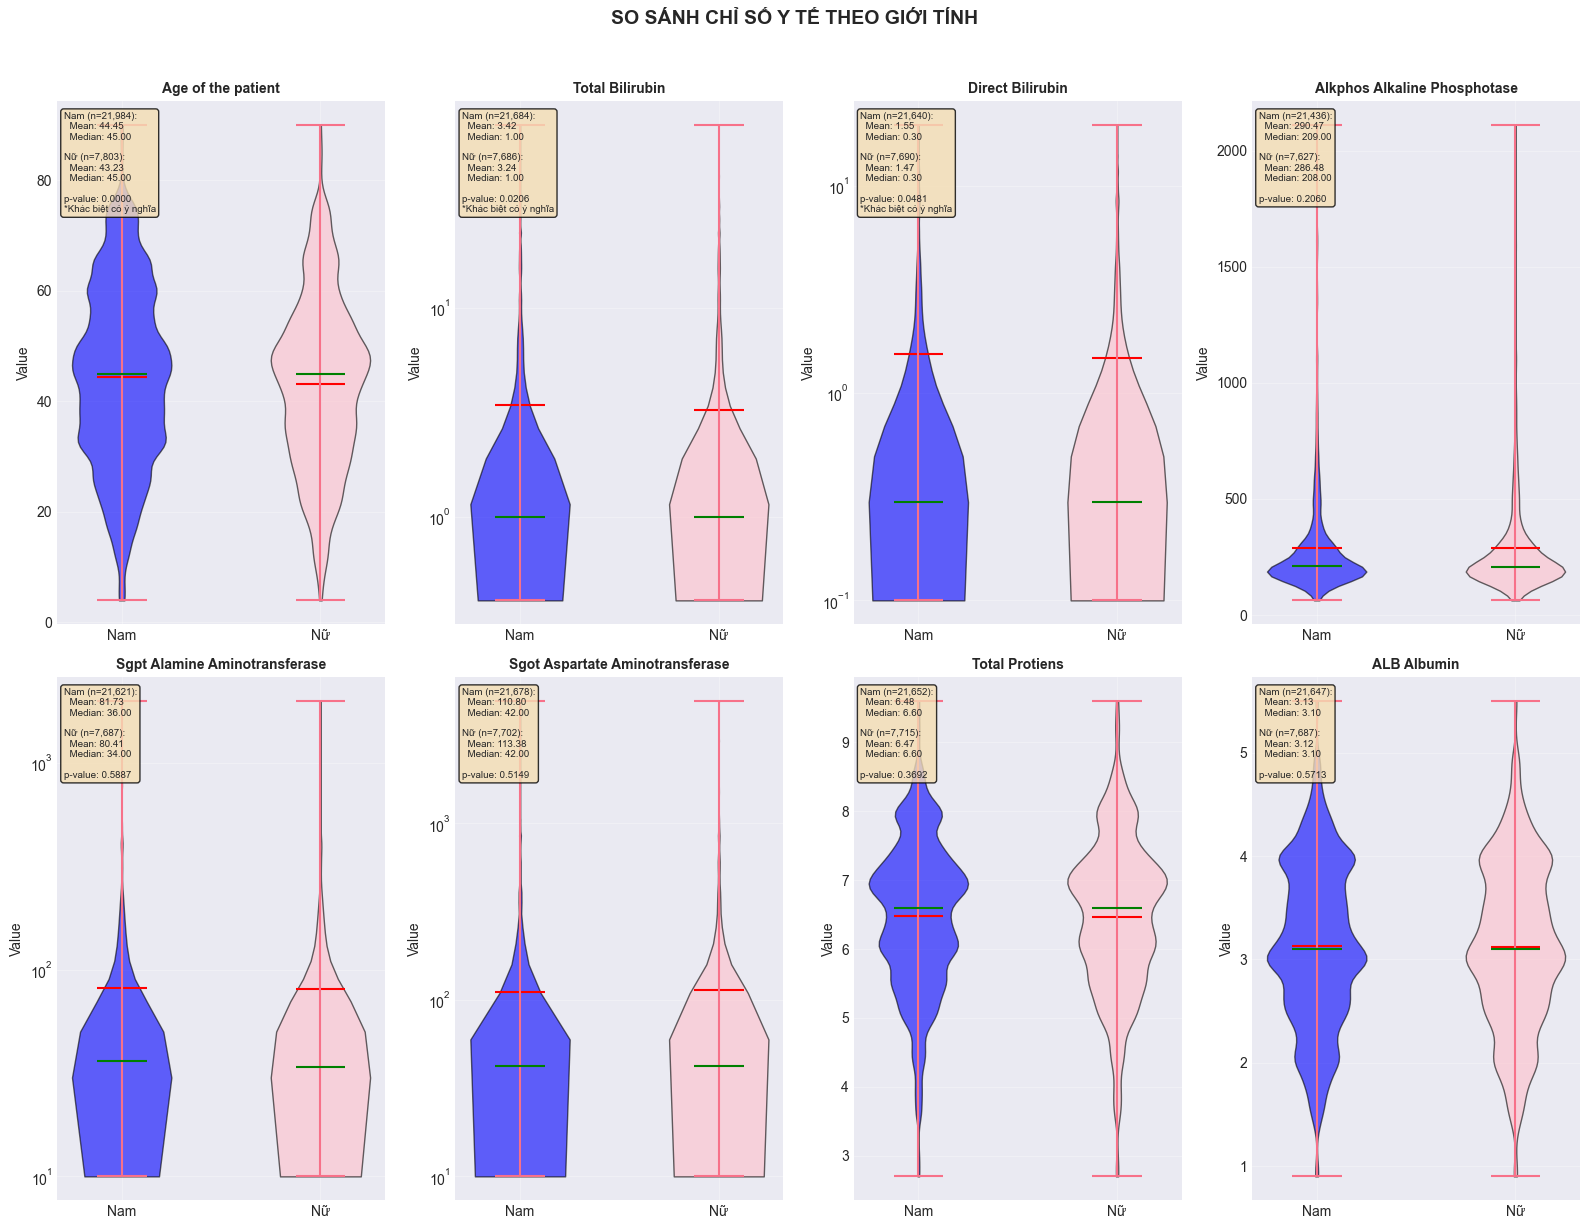

In [15]:
def plot_by_gender(df, figsize=(16, 12)):
    """
    Vẽ biểu đồ so sánh theo giới tính
    """
    if 'Gender of the patient' not in df.columns:
        print("Không tìm thấy cột giới tính")
        return
    
    # Chọn các cột y tế chính
    medical_cols = [
        'Age of the patient',
        'Total Bilirubin',
        'Direct Bilirubin',
        'Alkphos Alkaline Phosphotase',
        'Sgpt Alamine Aminotransferase',
        'Sgot Aspartate Aminotransferase',
        'Total Protiens',
        'ALB Albumin'
    ]
    
    # Lọc các cột có trong dataframe
    plot_cols = [col for col in medical_cols if col in df.columns]
    
    # Tạo figure
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    axes = axes.flatten()
    
    # Màu cho nam/nữ
    colors = {1: 'blue', 2: 'pink'}  # 1=nam, 2=nữ
    gender_labels = {1: 'Nam', 2: 'Nữ'}
    
    for idx, col in enumerate(plot_cols):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        
        # Dữ liệu theo giới tính
        data_male = df[df['Gender of the patient'] == 1][col].dropna()
        data_female = df[df['Gender of the patient'] == 2][col].dropna()
        
        # Kiểm tra có dữ liệu không
        if len(data_male) == 0 or len(data_female) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            continue
        
        # Vẽ violin plot
        violin_parts = ax.violinplot(
            [data_male, data_female],
            showmeans=True,
            showmedians=True
        )
        
        # Tô màu cho violin plot
        for pc, gender in zip(violin_parts['bodies'], [1, 2]):
            pc.set_facecolor(colors[gender])
            pc.set_alpha(0.6)
            pc.set_edgecolor('black')
        
        # Đặt màu cho mean và median
        violin_parts['cmeans'].set_color('red')
        violin_parts['cmedians'].set_color('green')
        
        # Tính toán thống kê
        stats_text = f"Nam (n={len(data_male):,}):\n"
        stats_text += f"  Mean: {data_male.mean():.2f}\n"
        stats_text += f"  Median: {data_male.median():.2f}\n\n"
        stats_text += f"Nữ (n={len(data_female):,}):\n"
        stats_text += f"  Mean: {data_female.mean():.2f}\n"
        stats_text += f"  Median: {data_female.median():.2f}"
        
        # Kiểm tra sự khác biệt (t-test)
        if len(data_male) > 30 and len(data_female) > 30:
            t_stat, p_value = stats.ttest_ind(data_male, data_female, equal_var=False)
            stats_text += f"\n\np-value: {p_value:.4f}"
            if p_value < 0.05:
                stats_text += "\n*Khác biệt có ý nghĩa"
        
        # Thêm thông tin thống kê
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=7,
               verticalalignment='top', bbox=props)
        
        # Cài đặt đồ thị
        ax.set_title(col, fontsize=10, fontweight='bold')
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Nam', 'Nữ'])
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        
        # Log scale nếu cần
        max_val = max(data_male.max(), data_female.max())
        median_val = max(data_male.median(), data_female.median())
        if max_val / median_val > 50 and median_val > 0:
            ax.set_yscale('log')
    
    # Ẩn axes không sử dụng
    for idx in range(len(plot_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('SO SÁNH CHỈ SỐ Y TẾ THEO GIỚI TÍNH', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

# Sử dụng:
fig3 = plot_by_gender(df)

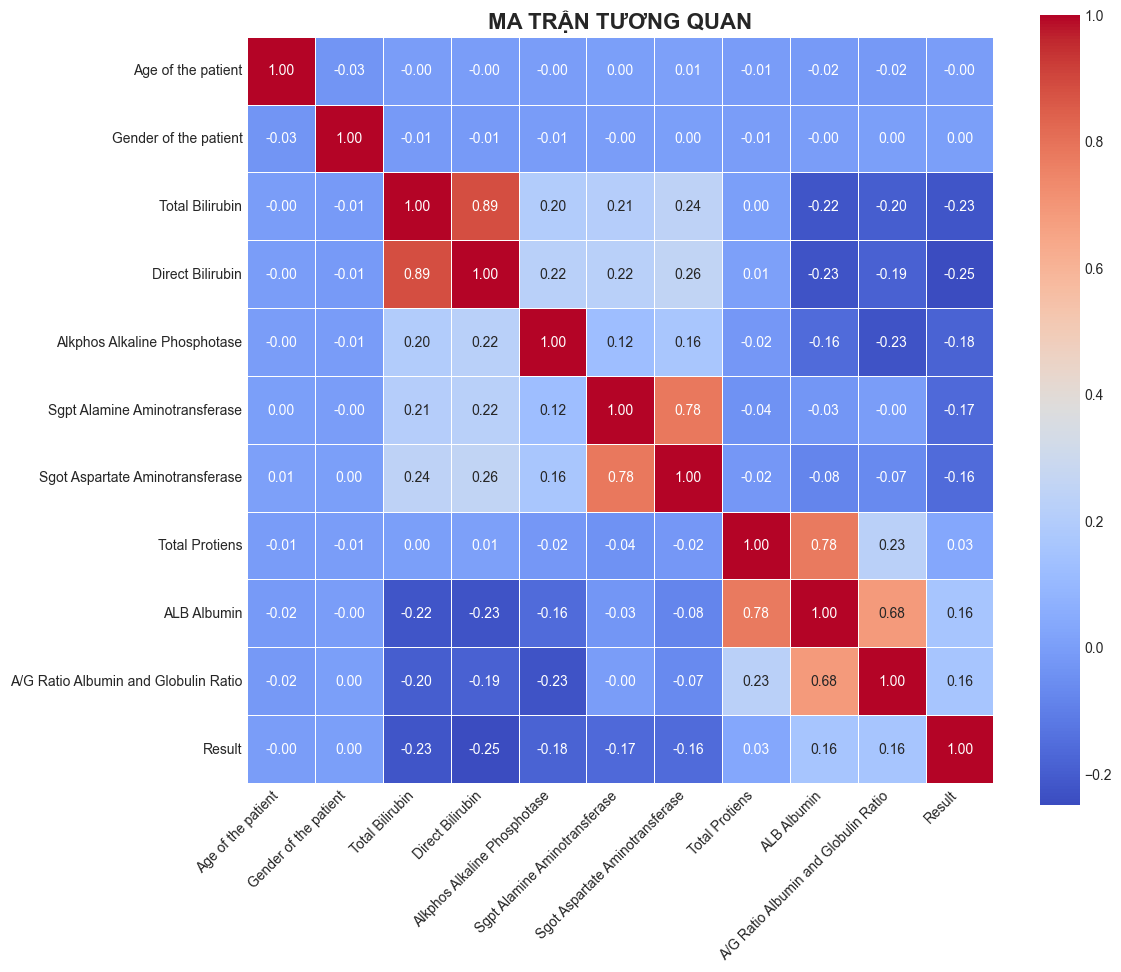

In [16]:
# Chỉ lấy cột số
numeric_df = df.select_dtypes(include=[np.number])

# Tính ma trận correlation
corr_matrix = numeric_df.corr()

# Vẽ heatmap ĐƠN GIẢN
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap="coolwarm",
            fmt=".2f",
            square=True,
            linewidths=0.5)

plt.title('MA TRẬN TƯƠNG QUAN', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\nahno\AppData\Local\Temp\ipykernel_11680\3489898710.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df_age.groupby('Age Group')[col].agg(['mean', 'std', 'count'])
C:\Users\nahno\AppData\Local\Temp\ipykernel_11680\3489898710.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df_age.groupby('Age Group')[col].agg(['mean', 'std', 'count'])
C:\Users\nahno\AppData\Local\Temp\ipykernel_11680\3489898710.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or ob

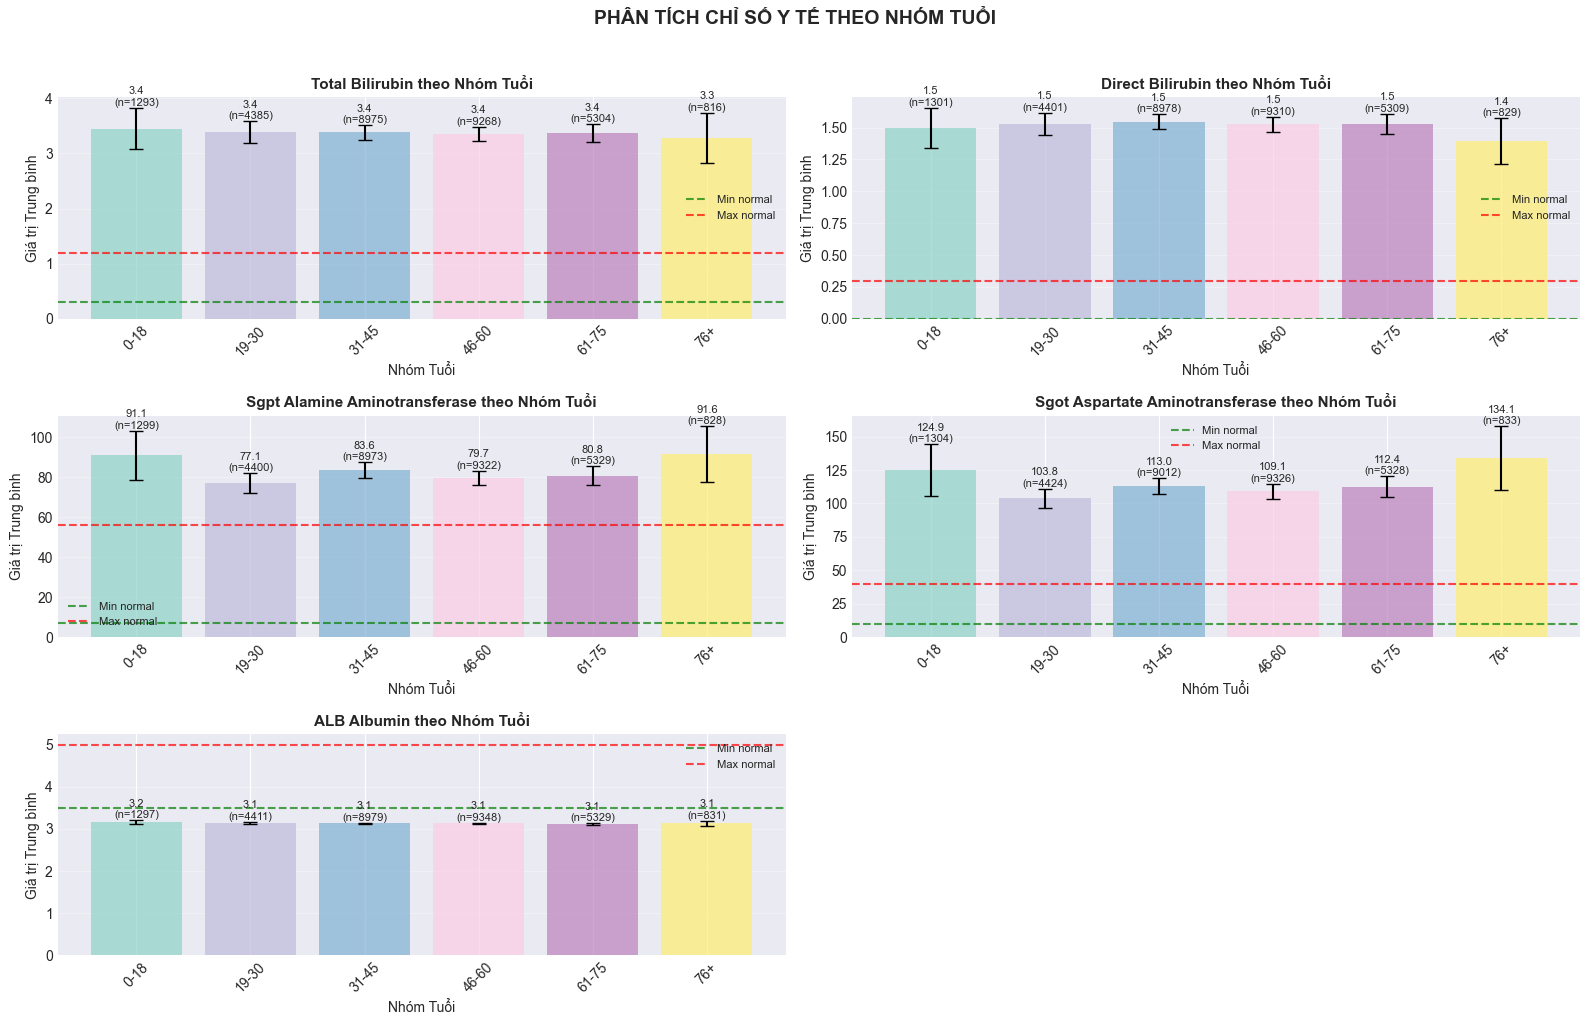

In [17]:
def plot_by_age_groups(df, figsize=(16, 10)):
    """
    Vẽ biểu đồ phân tích theo nhóm tuổi
    """
    if 'Age of the patient' not in df.columns:
        print("Không tìm thấy cột tuổi")
        return
    
    # Tạo nhóm tuổi
    bins = [0, 18, 30, 45, 60, 75, 100]
    labels = ['0-18', '19-30', '31-45', '46-60', '61-75', '76+']
    
    df_age = df.copy()
    df_age['Age Group'] = pd.cut(df_age['Age of the patient'], 
                                 bins=bins, labels=labels, right=False)
    
    # Chọn các chỉ số cần phân tích
    medical_cols = [
        'Total Bilirubin',
        'Direct Bilirubin',
        'Sgpt Alamine Aminotransferase',
        'Sgot Aspartate Aminotransferase',
        'ALB Albumin'
    ]
    
    plot_cols = [col for col in medical_cols if col in df.columns]
    
    # Tạo figure
    n_cols = 2
    n_rows = (len(plot_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, col in enumerate(plot_cols):
        ax = axes[idx]
        
        # Vẽ bar plot với error bars
        age_stats = df_age.groupby('Age Group')[col].agg(['mean', 'std', 'count'])
        
        # Tính confidence interval (95%)
        age_stats['ci'] = 1.96 * age_stats['std'] / np.sqrt(age_stats['count'])
        
        # Vẽ bar plot
        x_pos = np.arange(len(age_stats))
        bars = ax.bar(x_pos, age_stats['mean'], 
                     yerr=age_stats['ci'],
                     capsize=5, alpha=0.7,
                     color=plt.cm.Set3(np.linspace(0, 1, len(age_stats))))
        
        # Thêm số liệu trên mỗi bar
        for i, (mean_val, count_val) in enumerate(zip(age_stats['mean'], age_stats['count'])):
            ax.text(i, mean_val + age_stats['ci'].iloc[i], 
                   f'{mean_val:.1f}\n(n={int(count_val)})',
                   ha='center', va='bottom', fontsize=8)
        
        # Cài đặt đồ thị
        ax.set_title(f'{col} theo Nhóm Tuổi', fontsize=11, fontweight='bold')
        ax.set_xlabel('Nhóm Tuổi')
        ax.set_ylabel('Giá trị Trung bình')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(age_stats.index, rotation=45)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Thêm đường tiêu chuẩn y tế nếu có
        medical_standards = {
            'Total Bilirubin': (0.3, 1.2),
            'Direct Bilirubin': (0.0, 0.3),
            'Sgpt Alamine Aminotransferase': (7, 56),
            'Sgot Aspartate Aminotransferase': (10, 40),
            'ALB Albumin': (3.5, 5.0)
        }
        
        if col in medical_standards:
            normal_min, normal_max = medical_standards[col]
            ax.axhline(normal_min, color='green', linestyle='--', alpha=0.7, label=f'Min normal')
            ax.axhline(normal_max, color='red', linestyle='--', alpha=0.7, label=f'Max normal')
            ax.legend(fontsize=8)
    
    # Ẩn axes không sử dụng
    for idx in range(len(plot_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('PHÂN TÍCH CHỈ SỐ Y TẾ THEO NHÓM TUỔI', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

# Sử dụng:
fig5 = plot_by_age_groups(df)

#### 3. Chia dữ liệu Train/Test (loại bỏ duplicate)

In [18]:
# ===== XÓA DUPLICATE TRƯỚC KHI SPLIT =====
print(f"📊 LOẠI BỎ DUPLICATE:")
print("=" * 50)
print(f"Dữ liệu ban đầu: {len(df)} mẫu")

# Kiểm tra và xóa duplicate
duplicates = df.duplicated().sum()
print(f"Số dòng duplicate tìm thấy: {duplicates}")

df = df.drop_duplicates()
print(f"Dữ liệu sau khi loại bỏ duplicate: {len(df)} mẫu")
print(f"Đã xóa: {duplicates} dòng")


📊 LOẠI BỎ DUPLICATE:
Dữ liệu ban đầu: 30691 mẫu
Số dòng duplicate tìm thấy: 11323
Dữ liệu sau khi loại bỏ duplicate: 19368 mẫu
Đã xóa: 11323 dòng


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# =========================
# 1️⃣ TÁCH FEATURE & LABEL
# =========================
print("\n1️⃣ TÁCH FEATURE & LABEL")
X = df.drop(columns='Result')
y = df['Result']

print(f"   X shape: {X.shape}, y shape: {y.shape}")
print(f"   Các features: {X.columns.tolist()}")

# =========================
# 2️⃣ SPLIT TRAIN/TEST
# =========================
print("\n2️⃣ CHIA DỮ LIỆU TRAIN/TEST (stratified)")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"   Train shape: {X_train.shape}")
print(f"   Test  shape: {X_test.shape}")

cls_1_train = y_train[y_train==1]
cls_2_train = y_train[y_train==2]
print(f"\n   Train class distribution:")
print(f"   ├─ Có bệnh (1): {len(cls_1_train):,}")
print(f"   └─ Không bệnh (2): {len(cls_2_train):,}")

cls_1_test = y_test[y_test==1]
cls_2_test = y_test[y_test==2]
print(f"\n   Test class distribution:")
print(f"   ├─ Có bệnh (1): {len(cls_1_test):,}")
print(f"   └─ Không bệnh (2): {len(cls_2_test):,}")



1️⃣ TÁCH FEATURE & LABEL
   X shape: (19368, 10), y shape: (19368,)
   Các features: ['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', 'Alkphos Alkaline Phosphotase', 'Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', 'ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio']

2️⃣ CHIA DỮ LIỆU TRAIN/TEST (stratified)
   Train shape: (15494, 10)
   Test  shape: (3874, 10)

   Train class distribution:
   ├─ Có bệnh (1): 11,049
   └─ Không bệnh (2): 4,445

   Test class distribution:
   ├─ Có bệnh (1): 2,762
   └─ Không bệnh (2): 1,112


In [20]:
# ===== XUẤT DỮ LIỆU TRAIN/TEST RA FILE EXCEL =====
print("\n📁 XUẤT DỮ LIỆU RA FILE EXCEL:")
print("=" * 50)

# Tạo DataFrame cho train set (gốc - chưa scale)
df_train = X_train.copy()
df_train['Result'] = y_train.values

# Tạo DataFrame cho test set (gốc - chưa scale)
df_test = X_test.copy()
df_test['Result'] = y_test.values


# Xuất ra file Excel
try:
    with pd.ExcelWriter('data/liver_train_test_data.xlsx', engine='openpyxl') as writer:
        df_train.to_excel(writer, sheet_name='Train_Original', index=False)
        df_test.to_excel(writer, sheet_name='Test_Original', index=False)
    
    print(f"✅ Đã xuất file: data/liver_train_test_data.xlsx")
    print(f"\n📊 Thông tin các sheet:")
    print(f"  ├─ Train_Original: {df_train.shape[0]} mẫu × {df_train.shape[1]} cột (chưa chuẩn hóa)")
    print(f"  ├─ Test_Original:  {df_test.shape[0]} mẫu × {df_test.shape[1]} cột (chưa chuẩn hóa)")
    
except ImportError:
    print("⚠️ Cần cài đặt openpyxl: pip install openpyxl")
except Exception as e:
    print(f"❌ Lỗi khi xuất file: {e}")

# Bonus: Xuất thêm file CSV (nhẹ hơn Excel)
try:
    df_train.to_csv('data/train_original.csv', index=False, encoding='utf-8-sig')
    df_test.to_csv('data/test_original.csv', index=False, encoding='utf-8-sig')
    
    print(f"\n✅ Đã xuất thêm 4 file CSV vào thư mục data/")
except Exception as e:
    print(f"❌ Lỗi khi xuất CSV: {e}")


📁 XUẤT DỮ LIỆU RA FILE EXCEL:
✅ Đã xuất file: data/liver_train_test_data.xlsx

📊 Thông tin các sheet:
  ├─ Train_Original: 15494 mẫu × 11 cột (chưa chuẩn hóa)
  ├─ Test_Original:  3874 mẫu × 11 cột (chưa chuẩn hóa)

✅ Đã xuất thêm 4 file CSV vào thư mục data/


#### 3. Tiền xử lý dữ liệu

In [21]:
#Chiến lược: điền giá trị null bằng median, xử lý bằng tính tập train


# Điền giá trị null bằng median cho từng cột số
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    median_val = X_train[col].median()
    if X_train[col].isnull().sum() > 0:
        X_train[col].fillna(median_val, inplace=True)
    if X_test[col].isnull().sum() > 0:
        X_test[col].fillna(median_val, inplace = True)

# Xử lý cột non-numeric (gender)
if 'Gender of the patient' in df and df['Gender of the patient'].isnull().sum() > 0:
    mode_val = X_train['Gender of the patient'].mode()[0]
    X_train['Gender of the patient'].fillna(mode_val, inplace=True)
    X_test['Gender of the patient'].fillna(mode_val, inplace=True)
    print(f"  ✓ Gender of the patient: điền với mode = {mode_val}")


  ✓ Gender of the patient: điền với mode = 1.0


In [22]:
#nhận thấy: từ biểu đồ cool hot warm gì đấy, có biến Total Bilirubin và Direct Bilirubin có độ tương quan tới 0.89.
#Mà đối với KNN, khi 2 biến quá giống nhau, chúng sẽ làm nhiễu mô hình KNN, giống như kiểu một thông tin bị tính tới 2 lần trong hàm khoảng cách
#Chúng ta có 2 phương án, hoặc là bỏ đi biến direct Bilirubin vì total Bilirubin đã bao gồm direct Bilirubin rồi, hoặc là chỉnh sửa lại trọng
#số trong mô hình KNN
# hàm xóa cột 
def remove_column(data, column_name):
    if column_name not in data.columns:
        print(f"cột {column_name} không tồn tại trong data Frame")
        return data
    df_new = data.copy()
    df_new = df_new.drop(columns=[column_name])
    print(f"Đã xóa cột {column_name}")
    return df_new


In [23]:
# Xử lý outliner: sử dụng log transform (SẼ APPLY RIÊNG CHO TRAIN/TEST)
# Dữ liệu gốc:
# - SGPT: từ 10 đến 2000 (chênh lệch 200 lần!)
# - SGOT: từ 10 đến 4929 (chênh lệch 493 lần!)
# - Alkphos: từ 63 đến 2110
# → Khoảng cách quá lớn gây vấn đề cho KNN!

def log_transform(data, column_name):
    if column_name not in data.columns:
        print(f"cột {column_name} không tồn tại trong data Frame")
        return data
    df_new = data.copy()
    df_new[column_name] = np.log1p(df_new[column_name])
    print(f"Đã log transform cột {column_name}")
    return df_new


In [24]:
# =========================
# 3️⃣ TIỀN XỬ LÝ (LÀM RIÊNG TRAIN/TEST)
# =========================
print("\n3️⃣ TIỀN XỬ LÝ (LOG TRANSFORM + DROP COLUMN)")

# Xóa cột Direct Bilirubin (chỉ có data leakage từ Total Bilirubin)
print("\n   📍 Xóa cột Direct Bilirubin...")
X_train = X_train.drop(columns=['Direct Bilirubin'])
X_test = X_test.drop(columns=['Direct Bilirubin'])
print(f"      Train: {X_train.shape} | Test: {X_test.shape}")

# Log transform các cột có outlier
outlier_cols = [
    'Sgpt Alamine Aminotransferase',
    'Sgot Aspartate Aminotransferase',
    'Alkphos Alkaline Phosphotase'
]

print("\n   📍 Log Transform các cột outlier...")
for col in outlier_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])
    print(f"      ✓ {col}")

# =========================
# 4️⃣ OVERSAMPLE (TRAIN ONLY - ĐỢI ĐẾN SAU LOG TRANSFORM)
# =========================
print("\n4️⃣ OVERSAMPLE (SMOTE - TRAIN ONLY)")
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"   Class distribution after SMOTE (train):")
print(f"   ├─ Có bệnh (1): {(y_train==1).sum():,}")
print(f"   └─ Không bệnh (2): {(y_train==2).sum():,}")

# =========================
# 5️⃣ SCALE (FIT TRAIN – TRANSFORM TEST)
# =========================
print("\n5️⃣ CHUẨN HÓA DỮ LIỆU (StandardScaler)")

scaler = StandardScaler()

# Học mean & std từ TRAIN
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Áp dụng cùng công thức cho TEST (không refit)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"   ✓ Fit scaler từ TRAIN")
print(f"   ✓ Transform TEST bằng scaler từ TRAIN (NO LEAKAGE)")

print("\n✅ HOÀN THÀNH TIỀN XỬ LÝ")
print("=" * 70)


3️⃣ TIỀN XỬ LÝ (LOG TRANSFORM + DROP COLUMN)

   📍 Xóa cột Direct Bilirubin...
      Train: (15494, 9) | Test: (3874, 9)

   📍 Log Transform các cột outlier...
      ✓ Sgpt Alamine Aminotransferase
      ✓ Sgot Aspartate Aminotransferase
      ✓ Alkphos Alkaline Phosphotase

4️⃣ OVERSAMPLE (SMOTE - TRAIN ONLY)
   Class distribution after SMOTE (train):
   ├─ Có bệnh (1): 11,049
   └─ Không bệnh (2): 11,049

5️⃣ CHUẨN HÓA DỮ LIỆU (StandardScaler)
   ✓ Fit scaler từ TRAIN
   ✓ Transform TEST bằng scaler từ TRAIN (NO LEAKAGE)

✅ HOÀN THÀNH TIỀN XỬ LÝ


#### 5. Tìm Feature Importance từ Training Set


🌳 HUẤ LUYỆN RANDOM FOREST TRÊN TRAINING SET:

📊 FEATURE IMPORTANCE:
Total Bilirubin                         0.206047
Sgot Aspartate Aminotransferase         0.155914
Sgpt Alamine Aminotransferase           0.151103
Alkphos Alkaline Phosphotase            0.150541
A/G Ratio Albumin and Globulin Ratio    0.111792
ALB Albumin                             0.110122
Total Protiens                          0.108527
Age of the patient                      0.005275
Gender of the patient                   0.000680
dtype: float64


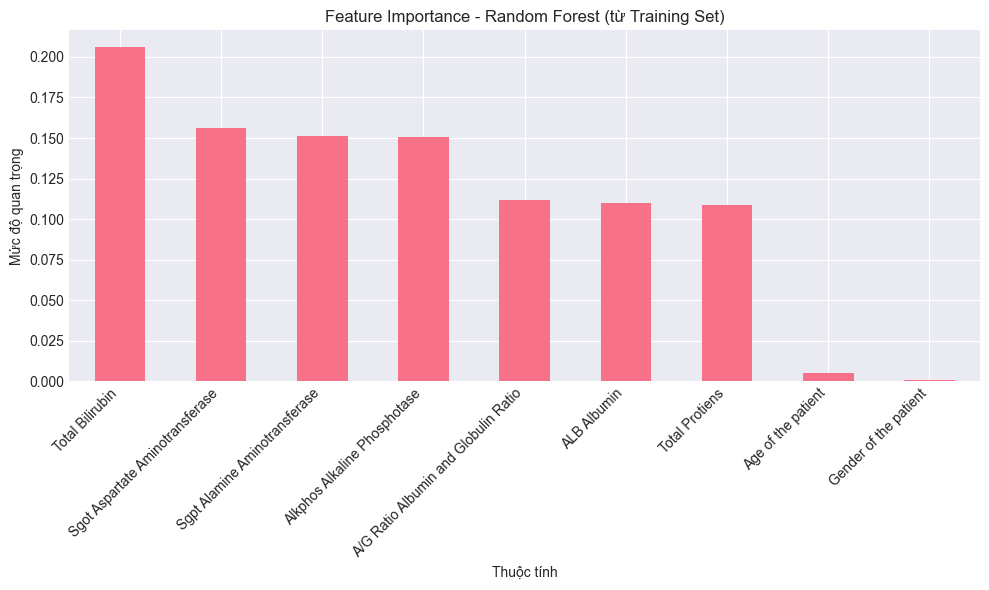


🎯 TOP 5 FEATURES CÓ ĐỘ QUAN TRỌNG CAO NHẤT:
   1. Total Bilirubin: 0.2060
   2. Sgot Aspartate Aminotransferase: 0.1559
   3. Sgpt Alamine Aminotransferase: 0.1511
   4. Alkphos Alkaline Phosphotase: 0.1505
   5. A/G Ratio Albumin and Globulin Ratio: 0.1118


In [25]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# ===== HUẤN LUYỆN RF TRÊN TRAINING SET =====
print("\n🌳 HUẤ LUYỆN RANDOM FOREST TRÊN TRAINING SET:")
print("=" * 50)

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_features="sqrt",
    random_state=42
)
rf_model.fit(X_train, y_train)

# Tính feature importance từ training set
importance_feature = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\n📊 FEATURE IMPORTANCE:")
print(importance_feature)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
importance_feature.plot(kind='bar')
plt.title("Feature Importance - Random Forest (từ Training Set)")
plt.ylabel("Mức độ quan trọng")
plt.xlabel("Thuộc tính")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Lấy top 5 features
top5_features = importance_feature.head(5).index.tolist()
print(f"\n🎯 TOP 5 FEATURES CÓ ĐỘ QUAN TRỌNG CAO NHẤT:")
for i, feat in enumerate(top5_features, 1):
    print(f"   {i}. {feat}: {importance_feature[feat]:.4f}")



#### 6.SO SÁNH ACCURACY: ALL FEATURES vs TOP 5 FEATURES

In [26]:
# ===== SO SÁNH ACCURACY: ALL FEATURES vs TOP 5 FEATURES =====
print("\n📈 SO SÁNH ACCURACY:")
print("=" * 50)

from sklearn.metrics import accuracy_score

# Accuracy với tất cả features
y_pred_all = rf_model.predict(X_test)
acc_all = accuracy_score(y_test, y_pred_all)

# Accuracy với top 5 features
rf_top5 = RandomForestClassifier(
    n_estimators=150,
    max_features="sqrt",
    random_state=42
)
rf_top5.fit(X_train[top5_features], y_train)
y_pred_top5 = rf_top5.predict(X_test[top5_features])
acc_top5 = accuracy_score(y_test, y_pred_top5)

# Get the number of features from X (all features except Result)
n_all_features = X.shape[1]

print(f"✓ Accuracy (All {n_all_features} features): {acc_all:.4f} ({acc_all*100:.2f}%)")
print(f"✓ Accuracy (Top 5 features): {acc_top5:.4f} ({acc_top5*100:.2f}%)")
print(f"✓ Chênh lệch: {abs(acc_all - acc_top5)*100:.2f}%")

if abs(acc_all - acc_top5) < 0.05:
    print("\n✅ Top 5 features đủ tốt để phân loại!")
else:
    print("\n⚠️ Nên xem xét sử dụng thêm features")


📈 SO SÁNH ACCURACY:
✓ Accuracy (All 10 features): 0.9946 (99.46%)
✓ Accuracy (Top 5 features): 0.9920 (99.20%)
✓ Chênh lệch: 0.26%

✅ Top 5 features đủ tốt để phân loại!



#### 7.CHUẨN BỊ DỮ LIỆU CHO TOP 5 FEATURE (CHUẨN HÓA)

In [27]:
# ===== CHUẨN BỊ DỮ LIỆU VỚI TOP 5 FEATURES =====
print("\n🎯 CHUẨN BỊ DỮ LIỆU VỚI TOP 5 FEATURES:")
print("=" * 50)

# Lọc top 5 features từ train và test
X_train_top5 = X_train[top5_features]
X_test_top5 = X_test[top5_features]

print(f"📋 Top 5 Features sử dụng:")
for i, feat in enumerate(top5_features, 1):
    print(f"   {i}. {feat}")

# Chuẩn hóa bằng scaler trên top 5 features
scaler_final = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_train_top5),
    columns=top5_features,
    index=X_train_top5.index
)

X_test_scaled = pd.DataFrame(
    scaler_final.transform(X_test_top5),
    columns=top5_features,
    index=X_test_top5.index
)

print(f"\n✅ DỮ LIỆU SẴN SÀNG:")
print(f"   Train shape: {X_train_scaled.shape}, y_train shape: {y_train.shape}")
print(f"   Test shape: {X_test_scaled.shape}, y_test shape: {y_test.shape}")



🎯 CHUẨN BỊ DỮ LIỆU VỚI TOP 5 FEATURES:
📋 Top 5 Features sử dụng:
   1. Total Bilirubin
   2. Sgot Aspartate Aminotransferase
   3. Sgpt Alamine Aminotransferase
   4. Alkphos Alkaline Phosphotase
   5. A/G Ratio Albumin and Globulin Ratio

✅ DỮ LIỆU SẴN SÀNG:
   Train shape: (22098, 5), y_train shape: (22098,)
   Test shape: (3874, 5), y_test shape: (3874,)



📊 PHÂN BỐ DỮ LIỆU TOP 5 FEATURES:


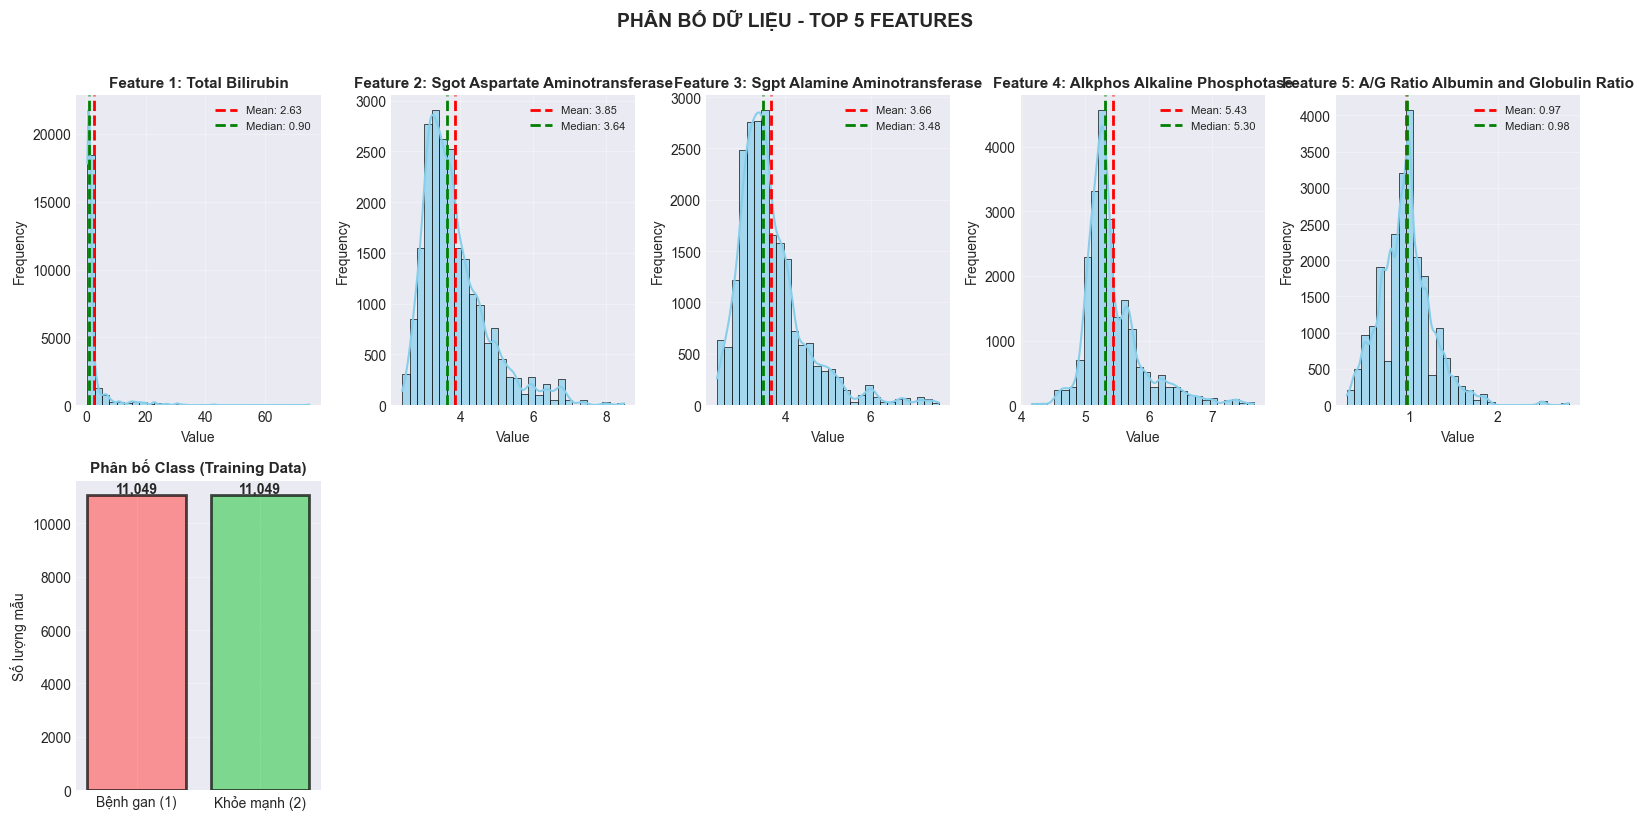


✅ Visualize hoàn tất!
   Top 5 Features: ['Total Bilirubin', 'Sgot Aspartate Aminotransferase', 'Sgpt Alamine Aminotransferase', 'Alkphos Alkaline Phosphotase', 'A/G Ratio Albumin and Globulin Ratio']
   Training samples: 22098
   Class distribution: {1: 11049, 2: 11049}


In [28]:
# ===== VẼ PHÂN BỐ DỮ LIỆU - TOP 5 FEATURES =====
print("\n📊 PHÂN BỐ DỮ LIỆU TOP 5 FEATURES:")
print("=" * 50)

import matplotlib.pyplot as plt
import seaborn as sns

# Tạo figure với subplots
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()

# Vẽ distribution cho từng feature
for idx, feat in enumerate(top5_features):
    ax = axes[idx]
    
    # Histogram với KDE
    sns.histplot(data=X_train_top5[feat], kde=True, ax=ax, 
                 bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Mean line
    mean_val = X_train_top5[feat].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    
    # Median line  
    median_val = X_train_top5[feat].median()
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    
    ax.set_title(f'Feature {idx+1}: {feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Vẽ class distribution
ax = axes[5]
class_counts = y_train.value_counts().sort_index()
bars = ax.bar(['Bệnh gan (1)', 'Khỏe mạnh (2)'], class_counts.values, 
               color=['#ff6b6b', '#51cf66'], alpha=0.7, edgecolor='black', linewidth=2)

# Thêm số lượng trên bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Phân bố Class (Training Data)', fontsize=11, fontweight='bold')
ax.set_ylabel('Số lượng mẫu')
ax.grid(True, alpha=0.3, axis='y')

# Ẩn axes không sử dụng
for idx in range(6, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('PHÂN BỐ DỮ LIỆU - TOP 5 FEATURES', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n✅ Visualize hoàn tất!")
print(f"   Top 5 Features: {top5_features}")
print(f"   Training samples: {len(X_train_top5)}")
print(f"   Class distribution: {class_counts.to_dict()}")


#### TÌM K TỐI ƯU 1: CHỌN K THEO ACCURACY


🔍 TÌM GIÁ TRỊ K TỐI ƯU:


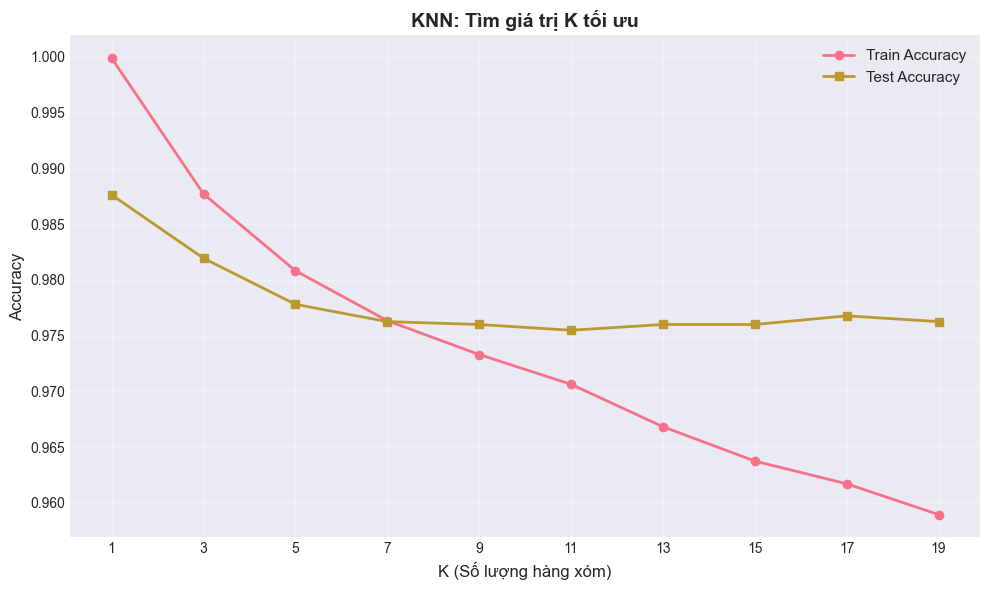


🎯 K TỐI ƯU: 1
   Test Accuracy: 0.9876 (98.76%)
   Train Accuracy: 0.9999


In [29]:
# ===== TÌM K TỐI ƯU =====
print("\n🔍 TÌM GIÁ TRỊ K TỐI ƯU:")
print("=" * 50)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Test các giá trị K từ 1 đến 20
k_values = range(1, 21, 2)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    
    train_scores.append(accuracy_score(y_train, train_pred))
    test_scores.append(accuracy_score(y_test, test_pred))

# Vẽ biểu đồ K optimization
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Train Accuracy', linewidth=2, markersize=6)
plt.plot(k_values, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=6)
plt.xlabel('K (Số lượng hàng xóm)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN: Tìm giá trị K tối ưu', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# Tìm K tốt nhất (test accuracy cao nhất)
best_k = list(k_values)[test_scores.index(max(test_scores))]
best_test_acc = max(test_scores)

print(f"\n🎯 K TỐI ƯU: {best_k}")
print(f"   Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")
print(f"   Train Accuracy: {train_scores[list(k_values).index(best_k)]:.4f}")


#### TÌM K TỐI ƯU 2: ELBOW METHOD

-Mục đích: tìm K “tối ưu” cho KNN (hoặc cluster K trong K-Means) dựa trên độ lỗi (error rate) hoặc cost function.

-Nguyên tắc: 

 * Khi tăng K:

    + Ban đầu, tăng K sẽ giảm đáng kể error rate → vì KNN bỏ bớt ảnh hưởng của nhiễu (noise).
    + Khi K quá lớn, lợi ích giảm dần → error rate cải thiện rất ít hoặc thậm chí bắt đầu tăng.

    + Điểm “elbow” là chỗ đường cong bắt đầu phẳng lại, giống hình cái cùi chỏ → chọn K ở đây vì:
        Vừa đơn giản (không quá nhiều neighbors)
        Vừa đạt hiệu quả (error rate gần thấp nhất)


🔎 ELBOW METHOD (Error rate) để gợi ý K tối ưu:


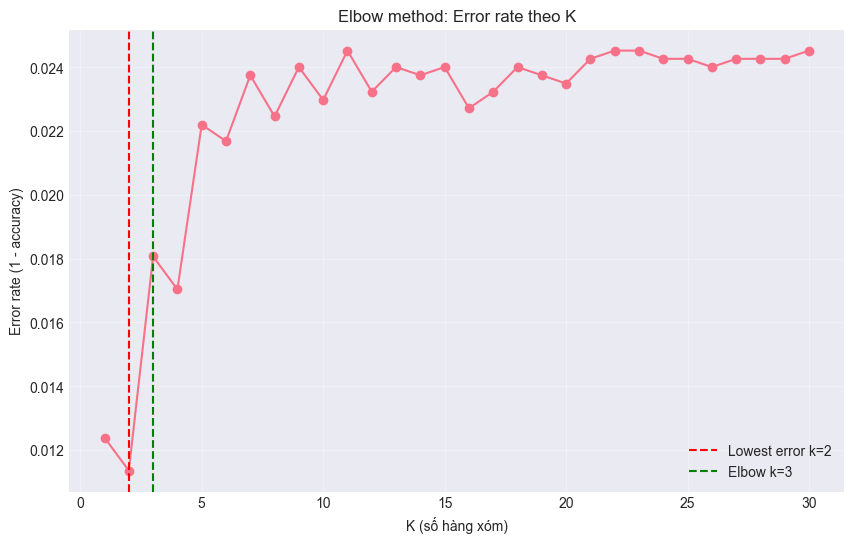


✅ Gợi ý: k (min error) = 2; k (elbow heuristic) = 3
Error rates sample (K=1..10): [0.0123902942694889, 0.01135776974703151, 0.018069179143004654, 0.017036654620547265, 0.022199277232834325, 0.02168301497160563, 0.02374806401652041, 0.022457408363448672, 0.024006195147134757, 0.022973670624677367]


In [30]:
# ===== ELBOW METHOD ĐỂ CHỌN K CHO KNN =====
print("\n🔎 ELBOW METHOD (Error rate) để gợi ý K tối ưu:")
print("=" * 50)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Khoảng K để thử (1..30)
k_range = range(1, 31)
error_rates = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    err = 1 - accuracy_score(y_test, preds)
    error_rates.append(err)

# Vẽ đồ thị error rate vs K
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), error_rates, marker='o', linestyle='-')
plt.xlabel('K (số hàng xóm)')
plt.ylabel('Error rate (1 - accuracy)')
plt.title('Elbow method: Error rate theo K')
plt.grid(alpha=0.3)

# K có error nhỏ nhất
best_k = list(k_range)[int(np.argmin(error_rates))]
plt.axvline(best_k, color='red', linestyle='--', label=f'Lowest error k={best_k}')

# heuristic: chọn elbow là điểm đầu tiên khi tỉ lệ cải thiện < 1% (diminishing returns)
elbow_k = None
for i in range(1, len(error_rates)):
    prev = error_rates[i-1]
    curr = error_rates[i]
    if prev > 0:
        improvement = prev - curr
        if improvement / prev < 0.01:
            elbow_k = list(k_range)[i]
            break
if elbow_k is None:
    elbow_k = best_k

plt.axvline(elbow_k, color='green', linestyle='--', label=f'Elbow k={elbow_k}')
plt.legend()
plt.show()

print(f"\n✅ Gợi ý: k (min error) = {best_k}; k (elbow heuristic) = {elbow_k}")
print(f"Error rates sample (K=1..10): {error_rates[:10]}")

#### TÌM K TỐI ƯU 3: K-FOLD CROSS-VALIDATION

- K-fold cross-validation (K-fold CV) là một kỹ thuật đánh giá mô hình nhằm ước lượng hiệu quả tổng quát (generalization) trên dữ liệu chưa thấy, đặc biệt khi dữ liệu không quá lớn.

Nguyên tắc:

- Chia dataset thành K phần (folds) bằng nhau.

- Lặp K lần, mỗi lần:

    + Chọn 1 fold làm validation set (dữ liệu để kiểm tra).

    + K fold còn lại làm train set (dữ liệu để huấn luyện).

Huấn luyện mô hình trên train set, tính độ chính xác (hoặc metric khác) trên validation set.

Sau K lần, tính trung bình metric → đây là ước lượng hiệu quả mô hình ổn định hơn chỉ dùng một train/test split.

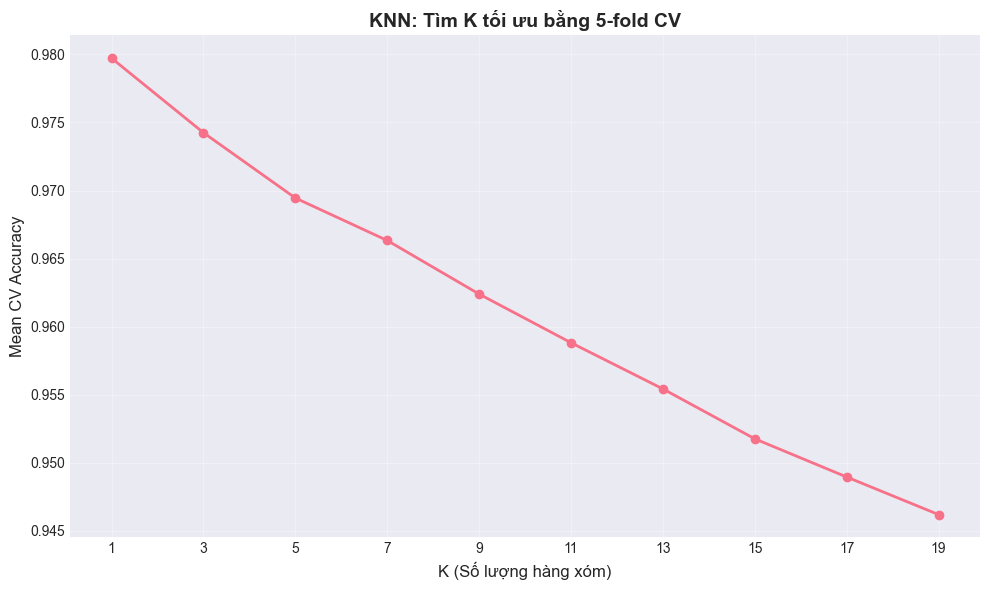


🎯 K TỐI ƯU: 1
   Mean CV Accuracy: 0.9797 (97.97%)


In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

# Các giá trị K muốn thử
k_values = range(1, 21, 2)
cv_scores = []

# Lặp qua các giá trị K
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 5-fold cross-validation trên tập train đã SMOTE
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Vẽ biểu đồ
plt.figure(figsize=(10,6))
plt.plot(k_values, cv_scores, 'o-', linewidth=2, markersize=6)
plt.xlabel('K (Số lượng hàng xóm)', fontsize=12)
plt.ylabel('Mean CV Accuracy', fontsize=12)
plt.title('KNN: Tìm K tối ưu bằng 5-fold CV', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# K tốt nhất
best_k = k_values[np.argmax(cv_scores)]
best_cv_acc = max(cv_scores)
print(f"\n🎯 K TỐI ƯU: {best_k}")
print(f"   Mean CV Accuracy: {best_cv_acc:.4f} ({best_cv_acc*100:.2f}%)")


#### Vậy, sau 3 phương pháp thử tìm k tối ưu khác nhau, ta có thể kết luận k tối ưu là 1

#### HUẤN LUYỆN KNN VỚI k TỐI ƯU


🚀 HUẤN LUYỆN MÔ HÌNH KNN VỚI K=1:

📊 KỂT QUẢ ĐÁNH GIÁ MÔ HÌNH KNN (K=1):
  ├─ Accuracy:  0.9876 (98.76%)
  ├─ Precision: 0.9956 (99.56%)
  ├─ Recall:    0.9870 (98.70%)
  └─ F1-Score:  0.9913

🔲 MA TRẬN NHẦM LẪN:
                      Dự đoán (1)   Dự đoán (2)
  Thực tế (1):      2726              36
  Thực tế (2):        12            1100

📈 BÁNG CÁO CHI TIẾT:
                    precision    recall  f1-score   support

   Có bệnh gan (1)       1.00      0.99      0.99      2762
Không bệnh gan (2)       0.97      0.99      0.98      1112

          accuracy                           0.99      3874
         macro avg       0.98      0.99      0.98      3874
      weighted avg       0.99      0.99      0.99      3874



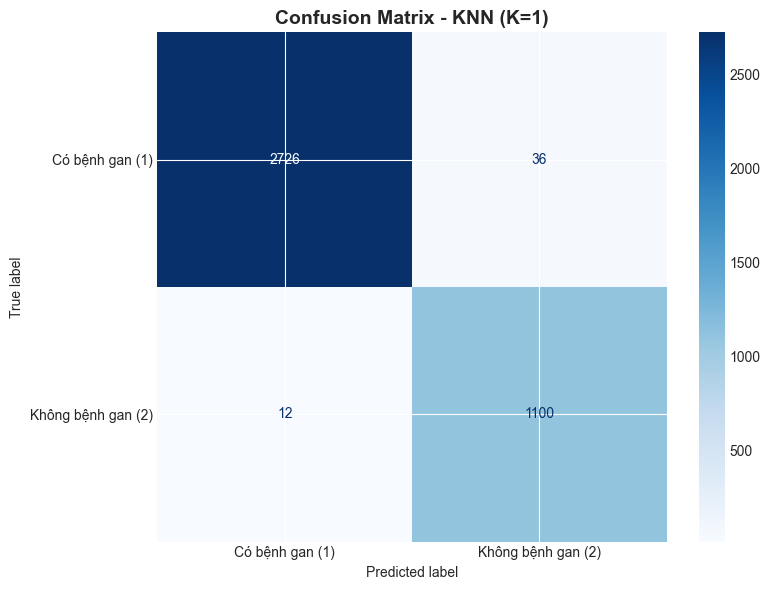


✅ MÔ HÌNH KNN HOÀN THÀNH!
  ├─ Số lượng features: 5
  ├─ K tối ưu: 1
  ├─ Accuracy: 98.76%
  ├─ Recall (phát hiện bệnh): 98.70%
  ├─ Dữ liệu train: 22098 mẫu
  └─ Dữ liệu test: 3874 mẫu


In [32]:
# ===== HUẤN LUYỆN MÔ HÌNH KNN CUỐI CÙNG =====
print(f"\n🚀 HUẤN LUYỆN MÔ HÌNH KNN VỚI K={best_k}:")


print("=" * 50)

# Tạo mô hình KNN với K tối ưu
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# Dự đoán trên tập test
y_pred = knn_final.predict(X_test_scaled)
y_pred_proba = knn_final.predict_proba(X_test_scaled)

# Tính các chỉ số đánh giá
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n📊 KỂT QUẢ ĐÁNH GIÁ MÔ HÌNH KNN (K={best_k}):")
print("=" * 60)
print(f"  ├─ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  ├─ Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  ├─ Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  └─ F1-Score:  {f1:.4f}")
print("=" * 60)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n🔲 MA TRẬN NHẦM LẪN:")
print(f"                      Dự đoán (1)   Dự đoán (2)")
print(f"  Thực tế (1):  {cm[0,0]:8d}        {cm[0,1]:8d}")
print(f"  Thực tế (2):  {cm[1,0]:8d}        {cm[1,1]:8d}")

# Chi tiết từng class
print(f"\n📈 BÁNG CÁO CHI TIẾT:")
print(classification_report(y_test, y_pred, target_names=['Có bệnh gan (1)', 'Không bệnh gan (2)']))

# Vẽ Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Có bệnh gan (1)', 'Không bệnh gan (2)'])
cm_display.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - KNN (K={best_k})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tóm tắt kết quả
print(f"\n✅ MÔ HÌNH KNN HOÀN THÀNH!")
print(f"  ├─ Số lượng features: {len(top5_features)}")
print(f"  ├─ K tối ưu: {best_k}")
print(f"  ├─ Accuracy: {accuracy*100:.2f}%")
print(f"  ├─ Recall (phát hiện bệnh): {recall*100:.2f}%")
print(f"  ├─ Dữ liệu train: {len(X_train_scaled)} mẫu")
print(f"  └─ Dữ liệu test: {len(X_test_scaled)} mẫu")


In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# ===== VẼ LEARNING CURVE =====
print(f"\n📈 VẼ ĐƯỜNG HỌC (LEARNING CURVE) CHO KNN (K={best_k}):")
print("=" * 60)

# Tính learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=KNeighborsClassifier(n_neighbors=best_k),
    X=X_train_scaled,
    y=y_train,
    cv=5,  # 5-fold cross-validation
    train_sizes=np.linspace(0.1, 1.0, 10),  # Từ 10% đến 100% dữ liệu train
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Tính mean và std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Vẽ đồ thị
plt.figure(figsize=(12, 7))

# Vẽ train score
plt.plot(train_sizes, train_mean, 'o-', color='blue', linewidth=2, 
         markersize=8, label='Train Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.2, color='blue')

# Vẽ validation score
plt.plot(train_sizes, val_mean, 's-', color='red', linewidth=2, 
         markersize=8, label='Validation Score (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.2, color='red')

# Thêm grid và labels
plt.xlabel('Số lượng mẫu huấn luyện', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title(f'Learning Curve - KNN (K={best_k})', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim(0.5, 1.05)

# Thêm thông tin chi tiết
info_text = f"Features: {len(top5_features)}\n"
info_text += f"K: {best_k}\n"
info_text += f"Final Train Acc: {train_mean[-1]:.4f}\n"
info_text += f"Final Val Acc: {val_mean[-1]:.4f}\n"
info_text += f"Gap: {abs(train_mean[-1] - val_mean[-1]):.4f}"

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Phân tích kết quả
print(f"\n📊 PHÂN TÍCH LEARNING CURVE:")
print("=" * 60)
print(f"  ├─ Train Accuracy cuối: {train_mean[-1]:.4f} (±{train_std[-1]:.4f})")
print(f"  ├─ Validation Accuracy cuối: {val_mean[-1]:.4f} (±{val_std[-1]:.4f})")
print(f"  └─ Gap (Overfitting): {abs(train_mean[-1] - val_mean[-1]):.4f}")

# Đánh giá
gap = abs(train_mean[-1] - val_mean[-1])
if gap < 0.05:
    print(f"\n✅ Mô hình KHÔNG bị overfitting (gap < 5%)")
    print(f"   → Train và Validation score rất gần nhau")
elif gap < 0.1:
    print(f"\n⚠️ Mô hình có DẤU HIỆU overfitting nhẹ (5% < gap < 10%)")
    print(f"   → Có thể cân nhắc: tăng K, giảm features, hoặc regularization")
else:
    print(f"\n❌ Mô hình BỊ OVERFITTING nặng (gap > 10%)")
    print(f"   → Cần: tăng K lớn hơn, giảm features, hoặc thêm dữ liệu")

# Kiểm tra high bias (underfitting)
if val_mean[-1] < 0.7:
    print(f"\n⚠️ Validation score thấp ({val_mean[-1]:.2%}) → có thể bị UNDERFITTING")
    print(f"   → Cần: giảm K, thêm features, hoặc thử mô hình phức tạp hơn")
elif val_mean[-1] >= 0.85:
    print(f"\n🎯 Validation score cao ({val_mean[-1]:.2%}) → mô hình TỐT!")
else:
    print(f"\n👍 Validation score ổn ({val_mean[-1]:.2%})")

print("\n" + "=" * 60)